**Table of contents**
1. [Set up and config](#1)
2. [Xử lý dữ liệu và EDA](#2)
3. [Mô hình và huấn luyện mô hình](#3)
4. [Đánh giá mô hình](#4)

# 1. Set up and config <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from dataclasses import dataclass
import scipy
import sklearn
import random

In [2]:
from preprocessing import load_data
from utils import learning_curve, loss_curve
from eval import (
  mcnemar_paired,
  reliability_diagram_multiclass
)

## Configuaration

In [3]:
# reproducibility
SEED = 42

# hyperparameters
LEARNING_RATE = .01
MAX_ITER = 10_000
REG = 1e-6
EPS = 1e-6
EPOCHS = 100
BATCH_SIZE = 100

# statistical significance level
ALPHA = .05

# data path
DATA_PATH = '../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx'

In [4]:
def set_seed(seed: int) -> None:
  random.seed(seed)
  np.random.seed(seed)

set_seed(SEED)

# 2. Xử lý dữ liệu và EDA <a id='2'></a>
- Không validation:
$\text{Train} : \text{Test} = 80\% : 20\%$
- Có validation:
$\text{Train} : \text{Val} : \text{Test} = 60\% : 20\% : 20\%$

## 2.1 Xử lý dữ liệu

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 1. LOAD DATA
df = load_data(DATA_PATH)

# 2. SEPARATE TARGET FROM FEATURES IMMEDIATELY
# This prevents the 'Class' column from being treated as a feature during scaling
X = df.drop('Class', axis=1)
y = df['Class']

# 3. SPLIT DATA FIRST (To prevent Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# 4. IDENTIFY COLUMN TYPES ON X_TRAIN
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# 5. IMPUTATION (Fit on Train, Transform on both)
# Numeric Imputer
num_imputer = SimpleImputer(strategy='mean')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Categorical Imputer (If there are any non-numeric features)
if not non_numeric_cols.empty:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[non_numeric_cols] = cat_imputer.fit_transform(X_train[non_numeric_cols])
    X_test[non_numeric_cols] = cat_imputer.transform(X_test[non_numeric_cols])

# 6. ENCODE FEATURES (If any)
label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# 7. ENCODE TARGET (y)
# 'Class' in Dry Bean is text (Seki, Barbunya, etc.), must be numbers for most models
target_le = LabelEncoder()
y_train = target_le.fit_transform(y_train)
y_test = target_le.transform(y_test)

# 8. STANDARDIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_val, X_val, y_train_val, y_val = train_test_split(X_train_scaled, y_train, test_size=0.25, random_state=SEED)

Data loaded successfully from ../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx


In [6]:
print(f"X_train_scaled.shape: {X_train_scaled.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test_scaled.shape: {X_test_scaled.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train_scaled.shape: (10888, 16)
y_train.shape: (10888,)
X_test_scaled.shape: (2723, 16)
y_test.shape: (2723,)


In [7]:
print(f"X_train_val.shape: {X_train_val.shape}")
print(f"y_train_val.shape: {y_train_val.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")

X_train_val.shape: (8166, 16)
y_train_val.shape: (8166,)
X_val.shape: (2722, 16)
y_val.shape: (2722,)


In [8]:
C = np.unique(y_train).shape[0]
print(f"Target classes identified: {target_le.classes_}")
print(f"Number of classes (C): {C}")

Target classes identified: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Number of classes (C): 7


## 2.2 EDA

# 3. Mô hình và huấn luyện mô hình <a id='3'></a>

## 3.1 Logistic Regression (nhị phân và đa lớp)

In [9]:
# from models import LogisticRegression

# logreg = LogisticRegression(reg=REG)
# logreg.fit(X=X_train_scaled, y=y_train, learning_rate=LEARNING_RATE, eps=EPS)
# logreg_preds = logreg.predict(X=X_test_scaled)
# logreg_eval = logreg.evaluate(y_pred=logreg_preds, y_true=y_test)
# print("Logistic Regression Evaluation:", logreg_eval)


### 3.1.x Laplace Approximation (Bayesian Logistic Regression)

In [10]:
from models import LogisticRegression

blr = LogisticRegression(learning_rate=LEARNING_RATE, eps=EPS)
blr.fit(X=X_train_scaled, y=y_train, solver='laplace_approximation')
blr_preds = blr.predict(X=X_test_scaled)
blr_eval = blr.evaluate(y_pred=blr_preds, y_true=y_test)
blr_acc = blr_eval['accuracy']
print(f'Bayesian Logistic Regression (Laplace Approximation) accuracy: {blr_acc:.2f}')

ValueError: LogisticRegression is binary-only; got 7 classes. Use SoftmaxRegression for multiclass problems.

## 3.2 Linear Discriminant Analysis - LDA và QDA

### 3.2.1 LDA và QDA

#### LDA

In [ ]:
from models import LDA

lda = LDA(reg=REG)
lda.fit(X=X_train_scaled, y=y_train)
lda_preds = lda.predict(X=X_test_scaled)
lda_eval = lda.evaluate(y_pred=lda_preds, y_true=y_test)
lda_acc = lda_eval['accuracy']
print(f'LDA accuracy: {lda_acc:.4f}')

LDA accuracy: 0.9104


#### QDA

In [ ]:
from models import QDA

qda = QDA(reg=REG)
qda.fit(X=X_train_scaled, y=y_train)
qda_preds = qda.predict(X=X_test_scaled)
qda_eval = qda.evaluate(y_pred=qda_preds, y_true=y_test)
qda_acc = qda_eval['accuracy']
print(f'QDA accuracy: {qda_acc:.4f}')

QDA accuracy: 0.9155


### 3.2.2 Fisher ratio feature ranking

For each feature $x_j$, we treat the projection direction as selecting that single coordinate, so the Fisher criterion becomes

$$
J(w_j) = J_j = \frac{\sum_{c=1}^{C} n_c (\mu_{c,j} - \mu_j)^2}{\sum_{c=1}^{C} n_c \, \sigma_{c,j}^2}
$$

where $n_c$ is the number of training samples in class $c$, $\mu_{c,j}$ and $\sigma_{c,j}^2$ are the class-wise mean and variance of feature $j$, and $\mu_j$ is the global mean of feature $j$. A larger $J_j$ means the feature separates classes better relative to its within-class spread.

In [ ]:
# Fisher ratio for each feature (multiclass version)
# J_j = sum_c n_c (mu_cj - mu_j)^2 / sum_c n_c sigma_cj^2

feature_names = list(X_train.columns)

classes, counts = np.unique(y_train, return_counts=True)
overall_mean = X_train_scaled.mean(axis=0)
fisher_scores = []

for j in range(X_train_scaled.shape[1]):
  between_class = 0.0
  within_class = 0.0

  for cls, n_c in zip(classes, counts):
    x_c = X_train_scaled[y_train == cls, j]
    mu_c = x_c.mean()
    var_c = x_c.var(ddof=1)

    between_class += n_c * (mu_c - overall_mean[j]) ** 2
    within_class += n_c * var_c

  fisher_scores.append(between_class / (within_class + 1e-12))

fisher_df = pd.DataFrame({
  'feature': feature_names,
  'fisher_ratio': fisher_scores,
}).sort_values('fisher_ratio', ascending=False).reset_index(drop=True)

print('Fisher ratio ranking (higher is better):')
fisher_df


Fisher ratio ranking (higher is better):


,feature,fisher_ratio
0,Area,12.553347
1,ConvexArea,12.530033
2,EquivDiameter,11.084359
3,Perimeter,10.629966
4,MinorAxisLength,9.701366
5,MajorAxisLength,9.472088
6,ShapeFactor2,5.381678
7,ShapeFactor1,5.307530
8,AspectRation,4.511665
9,Compactness,4.413558


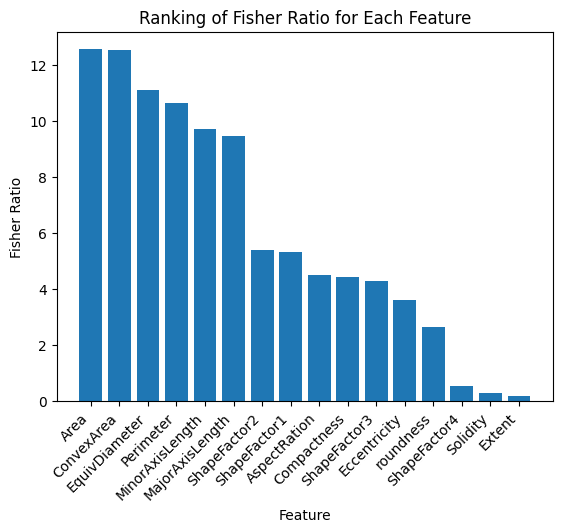

In [ ]:
plt.bar(fisher_df['feature'], fisher_df['fisher_ratio'])
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fisher Ratio')
plt.title('Ranking of Fisher Ratio for Each Feature')

plt.show()

### 3.2.3 Vẽ quy chiếu LDA xuống 2D và biểu diễn đường quyết định

LDA 2D projection captures about 0.7539 of the discriminative eigenvalue mass.


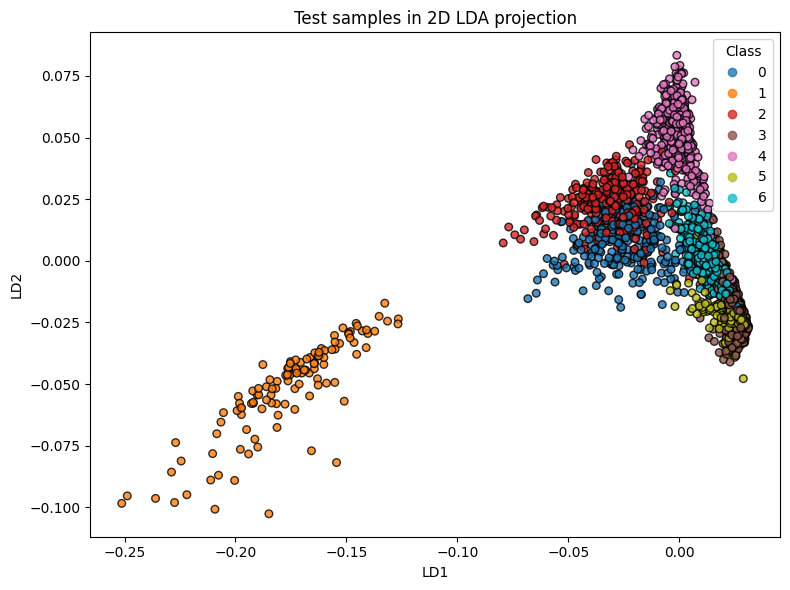

In [ ]:
# Project the data to 2D using the LDA model projection methods

lda_projection = LDA(reg=REG)
X_train_lda_2d = lda_projection.fit_transform(X_train_scaled, y_train, n_components=2)
X_test_lda_2d = lda_projection.transform(X_test_scaled, n_components=2)
explained_ratio = lda_projection.explained_discriminative_ratio(n_components=2)
print(f'LDA 2D projection captures about {explained_ratio.sum():.4f} of the discriminative eigenvalue mass.')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  alpha=0.8,
  edgecolor='k',
  s=30,
)
plt.title('Test samples in 2D LDA projection')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(*scatter.legend_elements(), title='Class', loc='best')
plt.tight_layout()
plt.show()

LDA accuracy on 2D projected space: 0.7279


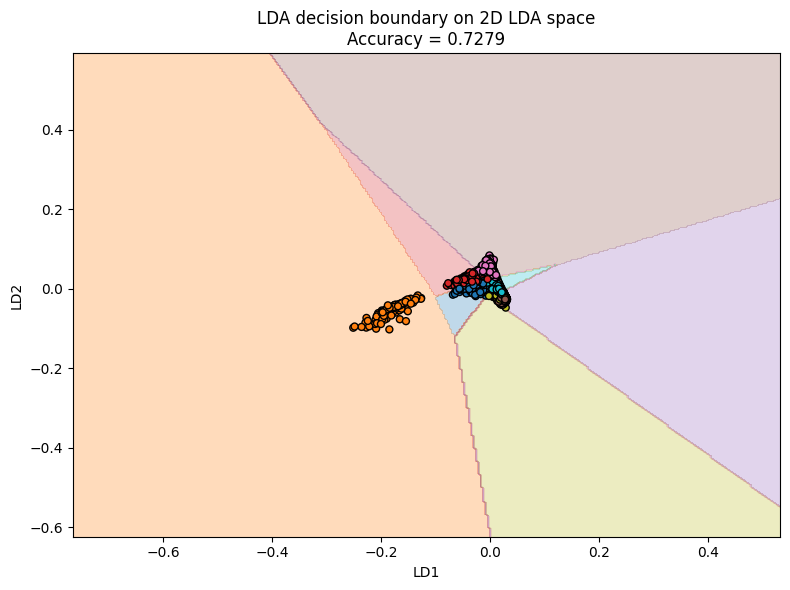

In [ ]:
# Fit LDA on the 2D projected space and draw its decision boundary

lda_2d = LDA(reg=REG)
lda_2d.fit(X_train_lda_2d, y_train)
lda_2d_preds_2d = lda_2d.predict(X_test_lda_2d)
lda_eval_2d = lda_2d.evaluate(lda_2d_preds_2d, y_test)
lda_acc_2d = lda_eval_2d['accuracy']
print(f'LDA accuracy on 2D projected space: {lda_acc_2d:.4f}')

all_points = np.vstack([X_train_lda_2d, X_test_lda_2d])
x_min, x_max = all_points[:, 0].min() - 0.5, all_points[:, 0].max() + 0.5
y_min, y_max = all_points[:, 1].min() - 0.5, all_points[:, 1].max() + 0.5
xx, yy = np.meshgrid(
  np.linspace(x_min, x_max, 300),
  np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
lda_grid = lda_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, lda_grid, alpha=0.28, cmap='tab10')
plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  edgecolor='k',
  s=25,
)
plt.title(f'LDA decision boundary on 2D LDA space\nAccuracy = {lda_acc_2d:.4f}')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.tight_layout()
plt.show()

### 3.2.4 When LDA is better than QDA, and vice versa

**When LDA is usually better**

- LDA assumes all classes share one covariance matrix, so it estimates far fewer parameters than QDA. This usually makes LDA more stable when the dataset is not very large or the feature space is fairly high-dimensional.
- If the classes mainly differ in their means, while their spread and orientation are similar, the linear boundary from LDA is often sufficient and generalizes better.
- LDA is also less likely to overfit when some classes do not have many training samples.

**When QDA is usually better**

- QDA allows each class to have its own covariance matrix, so it is more appropriate when classes have clearly different spreads, shapes, or orientations.
- If the class boundary is nonlinear, QDA can model it better because its decision surface is quadratic.
- When each class has enough data to estimate its covariance reliably, QDA can exploit that extra flexibility and outperform LDA.

**How to read the plots in this notebook**

- The 2D LDA projection keeps the two most discriminative directions, so it gives the clearest visual view of class separation.
- If the LDA boundary already follows the visible class regions well, then the shared-covariance assumption is likely reasonable.
- If the QDA boundary fits the visible clusters better, especially in curved or uneven-density regions, then class-specific covariance is likely important and QDA is the better model.
- If QDA produces a more complicated boundary without a meaningful gain in accuracy, then its extra flexibility is probably unnecessary and LDA is the safer choice.



### 3.2.5 Gaussian Naive Bayes (giả thiết độc lập) với LDA

In [ ]:
from models import GaussianNaiveBayes

gnb = GaussianNaiveBayes(reg=REG)
gnb.fit(X=X_train_scaled, y=y_train)
gnb_preds = gnb.predict(X=X_test_scaled)
gnb_eval = gnb.evaluate(gnb_preds, y_test)
gnb_acc = gnb_eval['accuracy']
print(f'Gaussian Naive Bayes accuracy: {gnb_acc:.4f}')

Gaussian Naive Bayes accuracy: 0.9038


## 3.3 Perceptron và Logistic Regression có Regularization

# 4. Đánh giá mô hình <a id='4'></a>

## 4.1 Đồ thị hàm mất mát theo số vòng lặp

## 4.2 Vẽ đường ranh giới quyết định trong không gian 2D

## 4.3 So sánh tất cả các mô hình trong một bảng kết quả thống nhất

## 4.4 k-fold cross-validation (k=5) và báo cáo $\text{mean} \pm \text{std}$ cho mỗi chỉ số

## 4.5 Vẽ **Precision-Recall curve** và so sánh Average Precision (AP) giữa các mô hình

## 4.6 McNemar's test

In [ ]:
pairs = [
  ('GNB', 'LDA', gnb_preds, lda_preds),
  ('GNB', 'QDA', gnb_preds, qda_preds),
  ('LDA', 'QDA', lda_preds, qda_preds),
  ('LR', 'BLR', logreg_preds, blr_preds),
]

for pair in pairs:
  name1, name2, preds1, preds2 = pair
  p_value = mcnemar_paired(preds1, preds2, y_test)
  print(f'McNemar test between {name1} and {name2}: p-value = {p_value:.4f}')
  if p_value < ALPHA:
    print(f'--> The difference between {name1} and {name2} is statistically significant at alpha={ALPHA}')
  else:
    print(f'--> No statistically significant difference between {name1} and {name2} at alpha={ALPHA}')

NameError: name 'gnb_preds' is not defined

## 4.7 Phân tích Calibration của xác suất đầu ra bằng reliability diagram.

In [ ]:
# Models already fitted earlier in the notebook
models_for_calibration = {
    'LDA': lda,
    'QDA': qda,
    'GNB': gnb,
    'BLR': blr,
    # 'LR': lr,   # uncomment if this model has predict_proba(...)
}

n_bins = 10
fig, axes = plt.subplots(1, len(models_for_calibration), figsize=(5 * len(models_for_calibration), 4), sharey=True)

if len(models_for_calibration) == 1:
  axes = [axes]

calibration_summary = []

for ax, (model_name, model) in zip(axes, models_for_calibration.items()):
  y_prob = model.predict_proba(X_test_scaled)

  bin_centers, counts, conf_mean, acc_mean, ece = reliability_diagram_multiclass(
    y_true=y_test,
    probs=y_prob,
    class_labels=model.classes_,
    n_bins=n_bins,
  )

  valid = ~np.isnan(conf_mean) & ~np.isnan(acc_mean)

  ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfect calibration')
  ax.plot(conf_mean[valid], acc_mean[valid], marker='o', linewidth=2, label='Observed')
  ax.bar(
    bin_centers,
    np.nan_to_num(acc_mean, nan=0.0),
    width=1.0 / n_bins,
    alpha=0.25,
    edgecolor='black',
  )

  ax.set_ylim(0, 1)

  calibration_summary.append({
    'model': model_name,
    'ece': ece,
    'avg_confidence': float(np.nanmean(conf_mean)),
    'avg_accuracy': float(np.nanmean(acc_mean)),
  })

axes[0].set_ylabel('Empirical accuracy')
axes[0].legend(loc='lower right')
plt.suptitle('Calibration analysis with reliability diagrams', y=1.02)
plt.tight_layout()
plt.show()

calibration_summary = sorted(calibration_summary, key=lambda x: x['ece'])
print('Calibration summary (lower ECE is better):')
for row in calibration_summary:
  print(
    f"{row['model']}: "
    f"ECE={row['ece']:.4f}, "
    f"avg_confidence={row['avg_confidence']:.4f}, "
    f"avg_accuracy={row['avg_accuracy']:.4f}"
  )